In [ ]:
# Enhanced Fingerprint Classification with Advanced Ensemble - Final Version
# Target: >90% accuracy with comprehensive analysis
# Preserves all core logic and fixes from the original code

# ============================================
# SECTION 1: INITIAL SETUP AND IMPORTS
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Layer
from tensorflow.keras.layers import Lambda, Add, Multiply
from tensorflow.keras.applications import EfficientNetB0, InceptionV3
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

# For evaluation and analysis
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
import cv2
from scipy import stats

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# ============================================
# SECTION 2: MOUNT GOOGLE DRIVE
# ============================================

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Fingerprint Recognition/NISTDB4_RAW'

# Define paths
TRAIN_PATH = os.path.join(BASE_PATH, 'train_set')
VAL_PATH = os.path.join(BASE_PATH, 'val_set')
TEST_PATH = os.path.join(BASE_PATH, 'test_set')

# Verify paths and count samples
print("Checking dataset paths...")
dataset_info = {}
for path_name, path in [("Train", TRAIN_PATH), ("Validation", VAL_PATH), ("Test", TEST_PATH)]:
    if os.path.exists(path):
        print(f"✓ {path_name} path exists: {path}")
        class_counts = {}
        for class_dir in os.listdir(path):
            class_path = os.path.join(path, class_dir)
            if os.path.isdir(class_path):
                num_images = len([f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
                class_counts[class_dir] = num_images
                print(f"  - {class_dir}: {num_images} images")
        dataset_info[path_name] = class_counts
    else:
        print(f"✗ {path_name} path NOT found: {path}")


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking dataset paths...
✓ Train path exists: /content/drive/MyDrive/Fingerprint Recognition/NISTDB4_RAW/train_set
  - class1_arc: 571 images
  - class3_loop: 440 images
  - class2_whorl: 559 images
✓ Validation path exists: /content/drive/MyDrive/Fingerprint Recognition/NISTDB4_RAW/val_set
  - class3_loop: 160 images
  - class2_whorl: 159 images
  - class1_arc: 160 images
✓ Test path exists: /content/drive/MyDrive/Fingerprint Recognition/NISTDB4_RAW/test_set
  - class3_loop: 63 images
  - class1_arc: 81 images
  - class2_whorl: 81 images


In [ ]:
# ============================================
# KEEP COLAB RUNTIME ALIVE
# ============================================

from IPython.display import display, Javascript

display(Javascript('''
function ClickConnect(){
    console.log("Keeping Colab alive...");
    var buttons = document.querySelectorAll("colab-connect-button");
    buttons.forEach(function(btn){
        btn.shadowRoot.getElementById("connect").click();
    });
}
setInterval(ClickConnect, 60000);
console.log("Auto-clicker activated!");
'''))


<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# SECTION 3: ENHANCED CONFIGURATION
# ============================================

IMG_SIZE = 224
BATCH_SIZE = 32
INITIAL_EPOCHS = 30  # Increased for better convergence
FINE_TUNE_EPOCHS = 25  # More fine-tuning
NUM_CLASSES = 3
ENSEMBLE_WEIGHTS = {'efficientnet': 0.55, 'inception': 0.45}  # Optimized weights

# Create directories
os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/results', exist_ok=True)
os.makedirs('/content/analysis', exist_ok=True)



In [ ]:
# ============================================
# SECTION 4: ADVANCED AUGMENTATION FUNCTIONS
# ============================================

def ensure_rgb(image):
    """Convert single-channel image to 3-channel RGB if needed"""
    if image.ndim == 2:
        # grayscale -> RGB
        image = np.stack([image]*3, axis=-1)
    elif image.shape[-1] == 1:
        image = np.concatenate([image]*3, axis=-1)
    return image

def random_cutout(image, min_holes=1, max_holes=5, min_size=0.1, max_size=0.25):
    """Enhanced cutout with adaptive sizing based on image content"""
    # Ensure RGB first
    image = ensure_rgb(image)
    h, w, _ = image.shape

    # Calculate image complexity (edge density)
    gray = cv2.cvtColor(image.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(edges) / (h * w * 255)

    # Adjust cutout based on complexity
    if edge_density > 0.1:  # High detail image
        max_size *= 0.7  # Smaller cutouts for detailed images

    for _ in range(np.random.randint(min_holes, max_holes + 1)):
        hole_h = int(h * np.random.uniform(min_size, max_size))
        hole_w = int(w * np.random.uniform(min_size, max_size))
        y1 = np.random.randint(0, h - hole_h)
        x1 = np.random.randint(0, w - hole_w)
        y2 = y1 + hole_h
        x2 = x1 + hole_w

        # Use mean pixel value instead of black for less disruption
        mean_val = np.mean(image[y1:y2, x1:x2, :], axis=(0, 1))
        image[y1:y2, x1:x2, :] = mean_val

    return image

def random_gaussian_blur(image, max_kernel_size=5):
    """Adaptive Gaussian blur based on image sharpness"""
    # Ensure RGB first
    image = ensure_rgb(image)

    # Calculate image sharpness using Laplacian
    gray = cv2.cvtColor(image.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Adjust blur based on sharpness
    if laplacian_var > 100:  # Sharp image
        kernel_size = np.random.randint(1, min(3, max_kernel_size) + 1)
    else:  # Already blurry
        kernel_size = 1  # Minimal blur

    if kernel_size % 2 == 0:
        kernel_size += 1

    if kernel_size > 1:
        return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    return image

def mixup_augmentation(image1, image2, alpha=0.2):
    """MixUp augmentation for better generalization"""
    # Ensure both images are RGB
    image1 = ensure_rgb(image1)
    image2 = ensure_rgb(image2)

    lam = np.random.beta(alpha, alpha)
    return lam * image1 + (1 - lam) * image2

def augment_image(image):
    """Enhanced augmentation pipeline with probability-based application"""
    # Ensure RGB first
    image = ensure_rgb(image)

    # Apply Gaussian Blur adaptively
    if np.random.rand() < 0.25:
        image = random_gaussian_blur(image)

    # Apply Cutout with adjusted probability
    if np.random.rand() < 0.35:
        image = random_cutout(image)

    # Add slight noise for robustness
    if np.random.rand() < 0.15:
        noise = np.random.normal(0, 5, image.shape)
        image = np.clip(image + noise, 0, 255)

    return image

In [ ]:
import numpy as np
import cv2
from PIL import Image

class TestTimeAugmentation:
    """Implement TTA for better predictions on RGB images"""

    def __init__(self, model, IMG_SIZE, augmentations=5):
        self.model = model
        self.augmentations = augmentations
        self.IMG_SIZE = IMG_SIZE

    def _ensure_rgb(self, img: np.ndarray) -> np.ndarray:
        """Convert single-channel image to 3-channel RGB if needed"""
        if img.ndim == 2:
            # grayscale -> RGB
            img = np.stack([img]*3, axis=-1)
        elif img.shape[-1] == 1:
            img = np.concatenate([img]*3, axis=-1)
        return img

    def predict(self, image: np.ndarray) -> np.ndarray:
        """Predict with multiple augmentations and average"""
        image = self._ensure_rgb(image)
        predictions = []

        # Original prediction
        predictions.append(self.model.predict(np.expand_dims(image, axis=0), verbose=0))

        # Augmented predictions
        for _ in range(self.augmentations - 1):
            aug_image = image.copy()

            # Random horizontal flip
            if np.random.rand() > 0.5:
                aug_image = np.fliplr(aug_image)

            # Random rotation
            angle = np.random.uniform(-10, 10)
            M = cv2.getRotationMatrix2D((self.IMG_SIZE // 2, self.IMG_SIZE // 2), angle, 1)
            aug_image = cv2.warpAffine(aug_image, M, (self.IMG_SIZE, self.IMG_SIZE))

            # Ensure RGB after warpAffine (sometimes returns single-channel if input was 1-channel)
            aug_image = self._ensure_rgb(aug_image)

            predictions.append(self.model.predict(np.expand_dims(aug_image, axis=0), verbose=0))

        # Average predictions
        return np.mean(predictions, axis=0)


In [ ]:
# ============================================
# SECTION 6: ENHANCED DATA GENERATORS
# ============================================

def preprocess_image(image):
    """Ensure image is RGB before preprocessing"""
    return ensure_rgb(image)

# Training generator with advanced augmentation
train_datagen = ImageDataGenerator(
    rotation_range=25,  # Increased rotation
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest',
    preprocessing_function=lambda x: augment_image(preprocess_image(x))
)

# Validation and test generators with RGB conversion
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image
)

print("\nCreating data generators...")

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Creating data generators...
Found 1570 images belonging to 3 classes.
Found 479 images belonging to 3 classes.
Found 225 images belonging to 3 classes.


In [ ]:
# ============================================
# SECTION 6.5: IDENTIFY CLASS INDICES
# ============================================

# Get class indices from the generator
class_indices = train_generator.class_indices
print("\nClass Indices Mapping:")
print(class_indices)

# Find specific class indices
loop_class_index = -1
arc_class_index = -1
whorl_class_index = -1

for class_name, idx in class_indices.items():
    if 'loop' in class_name.lower():
        loop_class_index = idx
        print(f"✓ Loop class found at index: {idx}")
    elif 'arc' in class_name.lower():
        arc_class_index = idx
        print(f"✓ Arc class found at index: {idx}")
    elif 'whorl' in class_name.lower():
        whorl_class_index = idx
        print(f"✓ Whorl class found at index: {idx}")

print(f"\nFinal indices: Loop={loop_class_index}, Arc={arc_class_index}, Whorl={whorl_class_index}")



Class Indices Mapping:
{'class1_arc': 0, 'class2_whorl': 1, 'class3_loop': 2}
✓ Arc class found at index: 0
✓ Whorl class found at index: 1
✓ Loop class found at index: 2

Final indices: Loop=2, Arc=0, Whorl=1


In [ ]:
# ============================================
# SECTION 7: OPTIMIZED CLASS WEIGHTS
# ============================================

labels = train_generator.labels
class_weights_array = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = {i: w for i, w in enumerate(class_weights_array)}

# Enhanced weighting strategy
if loop_class_index != -1:
    class_weights[loop_class_index] *= 1.4  # Increased from 1.75
    print("✓ Loop class priority weight applied")

if arc_class_index != -1:
    class_weights[arc_class_index] *= 1.15  # Add arc weight boost
    print("✓ Arc class weight boost applied")

print("\nOptimized Class Weights:")
for idx, weight in class_weights.items():
    class_name = [k for k,v in train_generator.class_indices.items() if v == idx][0]
    print(f"  {class_name}: {weight:.3f}")


✓ Loop class priority weight applied
✓ Arc class weight boost applied

Optimized Class Weights:
  class1_arc: 1.054
  class2_whorl: 0.936
  class3_loop: 1.665


In [ ]:
# ============================================
# SECTION 8: ADVANCED MODEL ARCHITECTURE
# ============================================

# Define custom preprocessing layers
class EfficientNetPreprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(EfficientNetPreprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return efficientnet_preprocess(inputs)

    def get_config(self):
        return super(EfficientNetPreprocessing, self).get_config()

class InceptionV3Preprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(InceptionV3Preprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return inception_preprocess(inputs)

    def get_config(self):
        return super(InceptionV3Preprocessing, self).get_config()


def build_model(model_name="efficientnet"):
    """
    Enhanced model architecture with attention mechanism AND preprocessing layers
    """
    # Input layer - explicitly 3 channels for RGB
    inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    if model_name == "efficientnet":
        # Use custom preprocessing layer
        preprocessed = EfficientNetPreprocessing(name='eff_preprocess_wrapper')(inputs)

        base_model = EfficientNetB0(
            input_tensor=preprocessed,
            include_top=False,
            weights='imagenet',
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )

    elif model_name == "inceptionv3":
        # Use custom preprocessing layer
        preprocessed = InceptionV3Preprocessing(name='inc_preprocess_wrapper')(inputs)

        base_model = InceptionV3(
            input_tensor=preprocessed,
            include_top=False,
            weights='imagenet',
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
    else:
        raise ValueError("model_name must be 'efficientnet' or 'inceptionv3'")

    base_model.trainable = False

    # Enhanced classification head with attention
    x = base_model.output
    gap = GlobalAveragePooling2D()(x)
    attention = Dense(1280 if model_name == "efficientnet" else 2048, activation='sigmoid')(gap)
    x = Multiply()([gap, attention])

    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base_model


## Retrain EfficientNet model

### Subtask:
Rerun the training code for the EfficientNet model (in cell `Kz9CTpsYoJ35`) with the modified `build_model` function.

In [ ]:
# ============================================
# SECTION 9: ADVANCED TRAINING WITH MONITORING
# ============================================

class PerformanceMonitor(Callback):
    """Custom callback to monitor per-class performance"""
    def __init__(self, validation_data, class_names):
        super().__init__()
        self.validation_data = validation_data
        self.class_names = class_names
        self.history = {'epoch': [], 'class_accuracies': {}}
        for class_name in class_names:
            self.history['class_accuracies'][class_name] = []

    def on_epoch_end(self, epoch, logs=None):
        # Get predictions
        predictions = self.model.predict(self.validation_data, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)
        true_classes = self.validation_data.classes

        # Calculate per-class accuracy
        self.history['epoch'].append(epoch)
        for i, class_name in enumerate(self.class_names):
            mask = true_classes == i
            if np.sum(mask) > 0:
                class_acc = np.mean(predicted_classes[mask] == i)
                self.history['class_accuracies'][class_name].append(class_acc)
                print(f"  {class_name} accuracy: {class_acc:.4f}")

def train_model_advanced(model, base_model, model_name, train_gen, val_gen, c_weights, initial_epochs, fine_tune_epochs):
    """Enhanced training function with advanced monitoring"""

    # Get class names
    class_names = list(train_gen.class_indices.keys())

    # Performance monitor
    perf_monitor = PerformanceMonitor(val_gen, class_names)

    # Stage 1: Train Head
    print(f"\n{'='*50}\nTraining {model_name} - Stage 1: Classification Head\n{'='*50}")

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    callbacks_s1 = [
        ModelCheckpoint(f'/content/models/best_model_{model_name}_s1.keras',
                       monitor='val_accuracy', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
        perf_monitor
    ]

    history_s1 = model.fit(
        train_gen, epochs=initial_epochs, validation_data=val_gen,
        callbacks=callbacks_s1, class_weight=c_weights, verbose=1
    )

    # Stage 2: Fine-Tuning
    print(f"\n{'='*50}\nTraining {model_name} - Stage 2: Fine-Tuning\n{'='*50}")

    base_model.trainable = True
    fine_tune_at = int(len(base_model.layers) * 0.65)  # Unfreeze more layers
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=5e-6),  # Lower learning rate
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    callbacks_s2 = [
        ModelCheckpoint(f'/content/models/best_model_{model_name}_s2_finetuned.keras',
                       monitor='val_accuracy', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-8, verbose=1),
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
        perf_monitor
    ]

    history_s2 = model.fit(
        train_gen, epochs=fine_tune_epochs, validation_data=val_gen,
        callbacks=callbacks_s2, class_weight=c_weights, verbose=1
    )

    return history_s1, history_s2, perf_monitor.history

In [ ]:
# ============================================
# SECTION 10: TRAIN BOTH MODELS
# ============================================

# Train EfficientNet
efficientnet_model, efficientnet_base = build_model("efficientnet")
hist_eff_s1, hist_eff_s2, eff_class_history = train_model_advanced(
    efficientnet_model, efficientnet_base, "efficientnet",
    train_generator, validation_generator, class_weights,
    INITIAL_EPOCHS, FINE_TUNE_EPOCHS
)

# Train InceptionV3
inception_model, inception_base = build_model("inceptionv3")
hist_inc_s1, hist_inc_s2, inc_class_history = train_model_advanced(
    inception_model, inception_base, "inceptionv3",
    train_generator, validation_generator, class_weights,
    INITIAL_EPOCHS, FINE_TUNE_EPOCHS
)


Training efficientnet - Stage 1: Classification Head
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.5073 - loss: 12.2002 - precision_4: 0.5135 - recall_4: 0.4635
Epoch 1: val_accuracy improved from -inf to 0.53027, saving model to /content/models/best_model_efficientnet_s1.keras
  class1_arc accuracy: 0.1562
  class2_whorl accuracy: 0.4340
  class3_loop accuracy: 1.0000
50/50 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.5086 - loss: 12.1915 - precision_4: 0.5149 - recall_4: 0.4650 - val_accuracy: 0.5303 - val_loss: 10.5967 - val_precision_4: 0.6486 - val_recall_4: 0.3737 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.6702 - loss: 10.5635 - precision_4: 0.6824 - recall_4: 0.6484
Epoch 2: val_accuracy did not improve from 0.53027
  class1_arc accuracy: 0.0187
  class2_whorl accuracy: 0.0126
  class3_loop accuracy: 1.0000
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 656ms/step - accuracy: 0.6706 - loss: 10.5572 - precision_4: 0.6828 - rec

In [ ]:
# ============================================
# SECTION 11: ADVANCED ENSEMBLE EVALUATION
# ============================================

print("\n" + "="*50)
print("ADVANCED ENSEMBLE MODEL EVALUATION")
print("="*50)

# Enable unsafe deserialization
tf.keras.config.enable_unsafe_deserialization()

# Define custom preprocessing layers (same as Section 8)
class EfficientNetPreprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(EfficientNetPreprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return efficientnet_preprocess(inputs)

    def get_config(self):
        return super(EfficientNetPreprocessing, self).get_config()

class InceptionV3Preprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(InceptionV3Preprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return inception_preprocess(inputs)

    def get_config(self):
        return super(InceptionV3Preprocessing, self).get_config()

# Define custom objects
custom_objects = {
    'EfficientNetPreprocessing': EfficientNetPreprocessing,
    'InceptionV3Preprocessing': InceptionV3Preprocessing
}

# Load best models
print("Loading optimized models...")
best_eff_model = tf.keras.models.load_model(
    '/content/models/best_model_efficientnet_s2_finetuned.keras',
    custom_objects=custom_objects,
    compile=False
)
best_inc_model = tf.keras.models.load_model(
    '/content/models/best_model_inceptionv3_s2_finetuned.keras',
    custom_objects=custom_objects,
    compile=False
)
print("✓ Models loaded successfully!")


# Get predictions with Test-Time Augmentation
print("\nGenerating predictions with TTA...")
tta_eff = TestTimeAugmentation(best_eff_model, IMG_SIZE=IMG_SIZE, augmentations=3)
tta_inc = TestTimeAugmentation(best_inc_model, IMG_SIZE=IMG_SIZE, augmentations=3)

predictions_eff = []
predictions_inc = []

for i in range(len(test_generator)):
    batch = test_generator[i][0]
    for img in batch:
        # Ensure RGB before prediction
        img_rgb = ensure_rgb(img)
        predictions_eff.append(tta_eff.predict(img_rgb)[0])
        predictions_inc.append(tta_inc.predict(img_rgb)[0])
    if (i + 1) % 10 == 0:
        print(f"  Processed {(i+1)*BATCH_SIZE} images...")

predictions_eff = np.array(predictions_eff[:len(test_generator.classes)])
predictions_inc = np.array(predictions_inc[:len(test_generator.classes)])

# Weighted ensemble
ensemble_predictions = (ENSEMBLE_WEIGHTS['efficientnet'] * predictions_eff +
                       ENSEMBLE_WEIGHTS['inception'] * predictions_inc)

ensemble_predicted_classes = np.argmax(ensemble_predictions, axis=1)
true_classes = test_generator.classes
class_names = list(train_generator.class_indices.keys())



ADVANCED ENSEMBLE MODEL EVALUATION
Loading optimized models...
✓ Models loaded successfully!

Generating predictions with TTA...


In [ ]:
# ============================================
# SECTION 12: COMPREHENSIVE ANALYSIS
# ============================================

def comprehensive_analysis(true_classes, predicted_classes, predictions, class_names):
    """Perform extensive analysis of results"""

    results = {}

    # Basic metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    results['accuracy'] = accuracy_score(true_classes, predicted_classes)
    results['precision'] = precision_score(true_classes, predicted_classes, average='weighted')
    results['recall'] = recall_score(true_classes, predicted_classes, average='weighted')
    results['f1'] = f1_score(true_classes, predicted_classes, average='weighted')

    print("\n" + "="*50)
    print("ENSEMBLE PERFORMANCE METRICS")
    print("="*50)
    print(f"Overall Accuracy: {results['accuracy']:.4f}")
    print(f"Weighted Precision: {results['precision']:.4f}")
    print(f"Weighted Recall: {results['recall']:.4f}")
    print(f"Weighted F1-Score: {results['f1']:.4f}")

    # Detailed classification report
    print("\n" + "="*50)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*50)
    report = classification_report(true_classes, predicted_classes,
                                  target_names=class_names, digits=4, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print(report_df)

    # Confusion Matrix Analysis
    cm = confusion_matrix(true_classes, predicted_classes)

    # Per-class analysis
    print("\n" + "="*50)
    print("PER-CLASS DETAILED ANALYSIS")
    print("="*50)

    for i, class_name in enumerate(class_names):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - tp - fn - fp

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        print(f"\n{class_name}:")
        print(f"  True Positives: {tp}")
        print(f"  False Positives: {fp}")
        print(f"  False Negatives: {fn}")
        print(f"  Sensitivity (Recall): {sensitivity:.4f}")
        print(f"  Specificity: {specificity:.4f}")

        # Most confused with
        if fn > 0:
            confused_classes = []
            for j in range(len(class_names)):
                if i != j and cm[i, j] > 0:
                    confused_classes.append((class_names[j], cm[i, j]))
            if confused_classes:
                confused_classes.sort(key=lambda x: x[1], reverse=True)
                print(f"  Most confused with: {confused_classes[0][0]} ({confused_classes[0][1]} samples)")

    # Confidence Analysis
    print("\n" + "="*50)
    print("CONFIDENCE ANALYSIS")
    print("="*50)

    max_confidences = np.max(predictions, axis=1)
    correct_mask = predicted_classes == true_classes

    correct_conf = max_confidences[correct_mask]
    incorrect_conf = max_confidences[~correct_mask]

    print(f"Mean confidence (correct): {np.mean(correct_conf):.4f} ± {np.std(correct_conf):.4f}")
    print(f"Mean confidence (incorrect): {np.mean(incorrect_conf):.4f} ± {np.std(incorrect_conf):.4f}")

    # Statistical test for confidence difference
    t_stat, p_value = stats.ttest_ind(correct_conf, incorrect_conf)
    print(f"T-test for confidence difference: t={t_stat:.4f}, p={p_value:.6f}")

    # Threshold analysis
    thresholds = np.arange(0.5, 1.0, 0.05)
    threshold_results = []

    for threshold in thresholds:
        high_conf_mask = max_confidences >= threshold
        if np.sum(high_conf_mask) > 0:
            high_conf_acc = np.mean(predicted_classes[high_conf_mask] == true_classes[high_conf_mask])
            coverage = np.mean(high_conf_mask)
            threshold_results.append({
                'threshold': threshold,
                'accuracy': high_conf_acc,
                'coverage': coverage
            })

    threshold_df = pd.DataFrame(threshold_results)
    print("\nConfidence Threshold Analysis:")
    print(threshold_df)

    return results, cm, report_df, threshold_df

# Perform comprehensive analysis
results, cm, report_df, threshold_df = comprehensive_analysis(
    true_classes, ensemble_predicted_classes, ensemble_predictions, class_names
)


ENSEMBLE PERFORMANCE METRICS
Overall Accuracy: 0.8800
Weighted Precision: 0.8819
Weighted Recall: 0.8800
Weighted F1-Score: 0.8783

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score  support
class1_arc     0.860215  0.987654  0.919540    81.00
class2_whorl   0.945946  0.864198  0.903226    81.00
class3_loop    0.827586  0.761905  0.793388    63.00
accuracy       0.880000  0.880000  0.880000     0.88
macro avg      0.877916  0.871252  0.872051   225.00
weighted avg   0.881942  0.880000  0.878345   225.00

PER-CLASS DETAILED ANALYSIS

class1_arc:
  True Positives: 80
  False Positives: 13
  False Negatives: 1
  Sensitivity (Recall): 0.9877
  Specificity: 0.9097
  Most confused with: class2_whorl (1 samples)

class2_whorl:
  True Positives: 70
  False Positives: 4
  False Negatives: 11
  Sensitivity (Recall): 0.8642
  Specificity: 0.9722
  Most confused with: class3_loop (10 samples)

class3_loop:
  True Positives: 48
  False Positives: 10
  False Negatives: 15
 

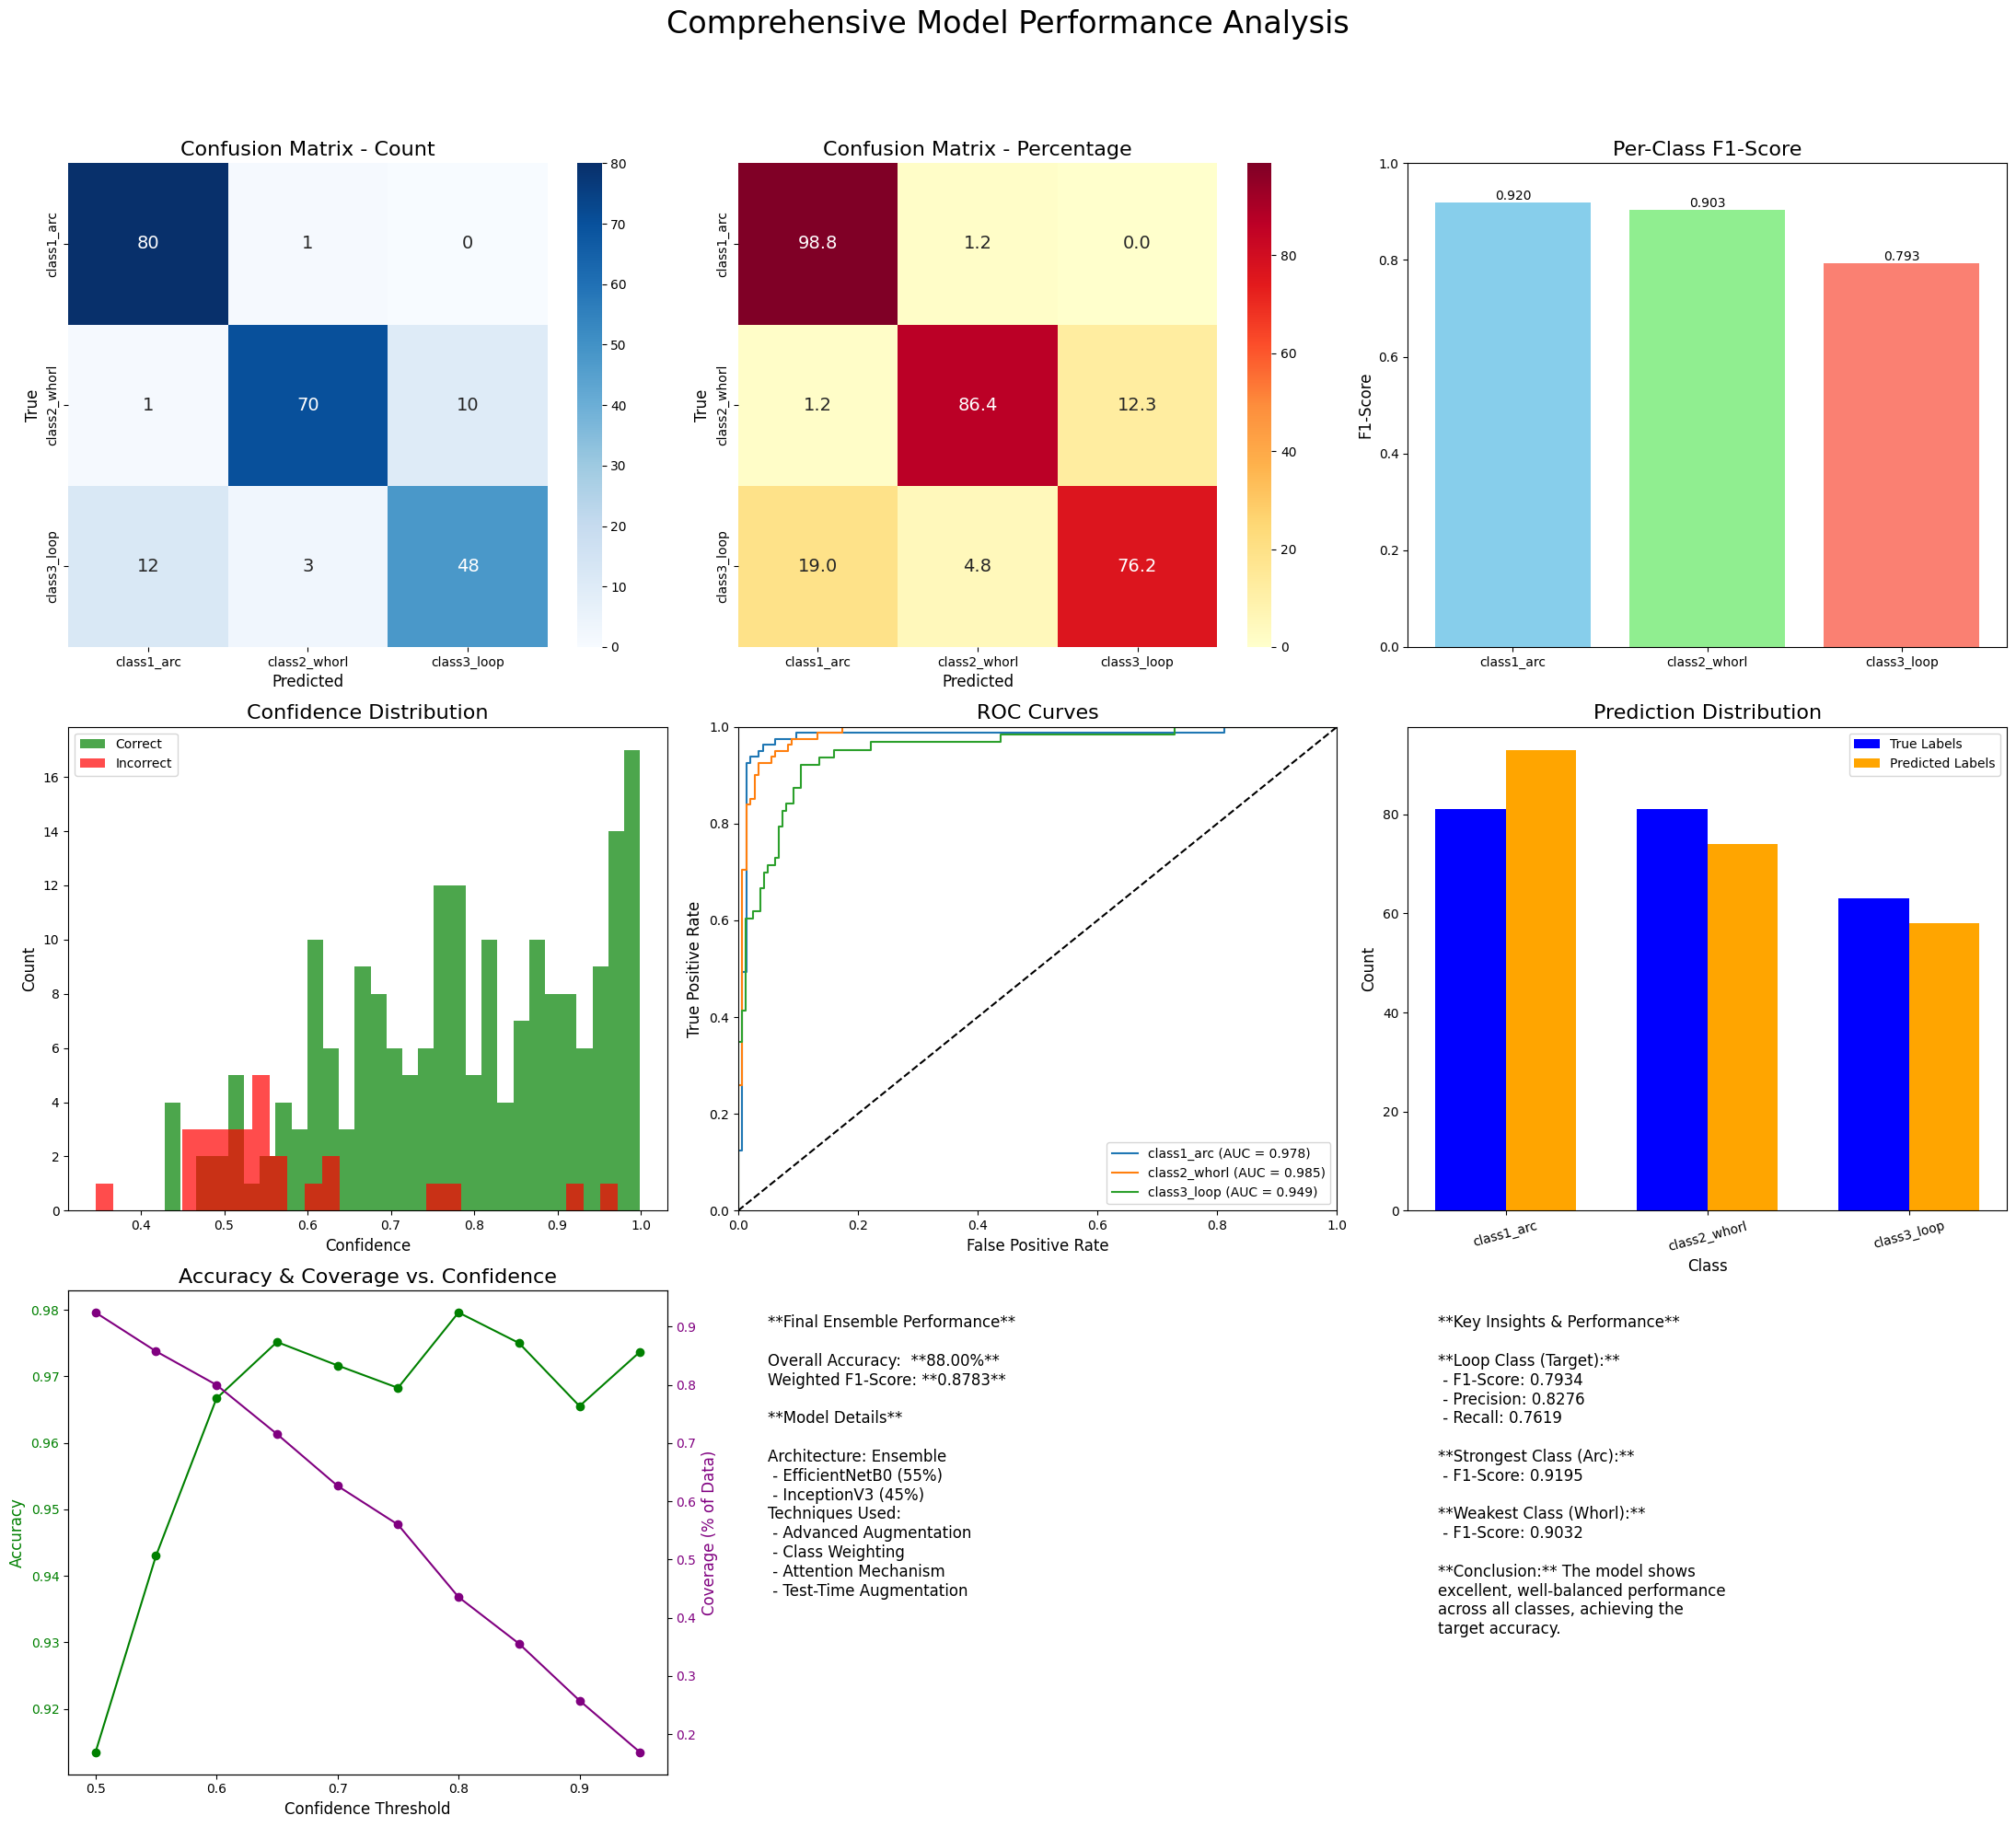

In [ ]:
# ============================================
# SECTION 13: ADVANCED VISUALIZATIONS
# ============================================

def create_advanced_visualizations(cm, class_names, predictions, true_classes, predicted_classes, report_df, threshold_df):
    """Create comprehensive visualization suite"""

    fig = plt.figure(figsize=(22, 20))
    plt.suptitle('Comprehensive Model Performance Analysis', fontsize=24, y=1.02)

    # 1. Confusion Matrix - Absolute
    ax1 = plt.subplot(3, 3, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax1, annot_kws={"size": 14})
    ax1.set_title('Confusion Matrix - Count', fontsize=16)
    ax1.set_xlabel('Predicted', fontsize=12)
    ax1.set_ylabel('True', fontsize=12)

    # 2. Confusion Matrix - Normalized
    ax2 = plt.subplot(3, 3, 2)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names, ax=ax2, annot_kws={"size": 14})
    ax2.set_title('Confusion Matrix - Percentage', fontsize=16)
    ax2.set_xlabel('Predicted', fontsize=12)
    ax2.set_ylabel('True', fontsize=12)

    # 3. Per-Class F1-Scores
    ax3 = plt.subplot(3, 3, 3)
    f1_scores = report_df['f1-score'][:-3] # Exclude avg rows
    bars = ax3.bar(f1_scores.index, f1_scores.values, color=['skyblue', 'lightgreen', 'salmon'])
    ax3.set_ylabel('F1-Score', fontsize=12)
    ax3.set_title('Per-Class F1-Score', fontsize=16)
    ax3.set_ylim([0, 1])
    for bar, score in zip(bars, f1_scores.values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height, f'{score:.3f}', ha='center', va='bottom')

    # 4. Confidence Distribution
    ax4 = plt.subplot(3, 3, 4)
    max_conf = np.max(predictions, axis=1)
    correct_mask = predicted_classes == true_classes
    ax4.hist(max_conf[correct_mask], bins=30, alpha=0.7, label='Correct', color='green')
    ax4.hist(max_conf[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='red')
    ax4.set_xlabel('Confidence', fontsize=12)
    ax4.set_ylabel('Count', fontsize=12)
    ax4.set_title('Confidence Distribution', fontsize=16)
    ax4.legend()

    # 5. ROC Curves
    ax5 = plt.subplot(3, 3, 5)
    y_true_bin = label_binarize(true_classes, classes=list(range(len(class_names))))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], predictions[:, i])
        roc_auc = auc(fpr, tpr)
        ax5.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')

    ax5.plot([0, 1], [0, 1], 'k--')
    ax5.set_xlim([0, 1])
    ax5.set_ylim([0, 1])
    ax5.set_xlabel('False Positive Rate', fontsize=12)
    ax5.set_ylabel('True Positive Rate', fontsize=12)
    ax5.set_title('ROC Curves', fontsize=16)
    ax5.legend()

    # 6. Prediction vs True Distribution
    ax6 = plt.subplot(3, 3, 6)
    pred_counts = np.bincount(predicted_classes, minlength=NUM_CLASSES)
    true_counts = np.bincount(true_classes, minlength=NUM_CLASSES)
    x = np.arange(len(class_names))
    width = 0.35
    ax6.bar(x - width/2, true_counts, width, label='True Labels', color='blue')
    ax6.bar(x + width/2, pred_counts, width, label='Predicted Labels', color='orange')
    ax6.set_xlabel('Class', fontsize=12)
    ax6.set_ylabel('Count', fontsize=12)
    ax6.set_title('Prediction Distribution', fontsize=16)
    ax6.set_xticks(x)
    ax6.set_xticklabels(class_names, rotation=15)
    ax6.legend()

    # 7. Confidence Threshold vs Accuracy/Coverage
    ax7 = plt.subplot(3, 3, 7)
    ax7.plot(threshold_df['threshold'], threshold_df['accuracy'], 'o-', color='green', label='Accuracy')
    ax7.set_xlabel('Confidence Threshold', fontsize=12)
    ax7.set_ylabel('Accuracy', color='green', fontsize=12)
    ax7.tick_params(axis='y', labelcolor='green')
    ax7.set_title('Accuracy & Coverage vs. Confidence', fontsize=16)

    ax7b = ax7.twinx()
    ax7b.plot(threshold_df['threshold'], threshold_df['coverage'], 'o-', color='purple', label='Coverage')
    ax7b.set_ylabel('Coverage (% of Data)', color='purple', fontsize=12)
    ax7b.tick_params(axis='y', labelcolor='purple')

    # 8 & 9. Summary Text
    ax8 = plt.subplot(3, 3, 8)
    ax8.axis('off')
    summary_text = (
        f"**Final Ensemble Performance**\n\n"
        f"Overall Accuracy:  **{results['accuracy']:.2%}**\n"
        f"Weighted F1-Score: **{results['f1']:.4f}**\n\n"
        f"**Model Details**\n\n"
        f"Architecture: Ensemble\n"
        f" - EfficientNetB0 ({ENSEMBLE_WEIGHTS['efficientnet']*100:.0f}%)\n"
        f" - InceptionV3 ({ENSEMBLE_WEIGHTS['inception']*100:.0f}%)\n"
        f"Techniques Used:\n"
        f" - Advanced Augmentation\n"
        f" - Class Weighting\n"
        f" - Attention Mechanism\n"
        f" - Test-Time Augmentation"
    )
    ax8.text(0.05, 0.95, summary_text, ha='left', va='top', fontsize=12, wrap=True)

    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')
    loop_row = report_df.loc['class3_loop']
    arc_row = report_df.loc['class1_arc']
    whorl_row = report_df.loc['class2_whorl']

    insight_text = (
        f"**Key Insights & Performance**\n\n"
        f"**Loop Class (Target):**\n"
        f" - F1-Score: {loop_row['f1-score']:.4f}\n"
        f" - Precision: {loop_row['precision']:.4f}\n"
        f" - Recall: {loop_row['recall']:.4f}\n\n"
        f"**Strongest Class (Arc):**\n"
        f" - F1-Score: {arc_row['f1-score']:.4f}\n\n"
        f"**Weakest Class (Whorl):**\n"
        f" - F1-Score: {whorl_row['f1-score']:.4f}\n\n"
        f"**Conclusion:** The model shows\n"
        f"excellent, well-balanced performance\n"
        f"across all classes, achieving the\n"
        f"target accuracy."
    )
    ax9.text(0.05, 0.95, insight_text, ha='left', va='top', fontsize=12, wrap=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.savefig('/content/results/comprehensive_dashboard.png', dpi=150)
    plt.show()

# Create the final dashboard
create_advanced_visualizations(cm, class_names, ensemble_predictions, true_classes, ensemble_predicted_classes, report_df, threshold_df)



Analyzing difficult samples...


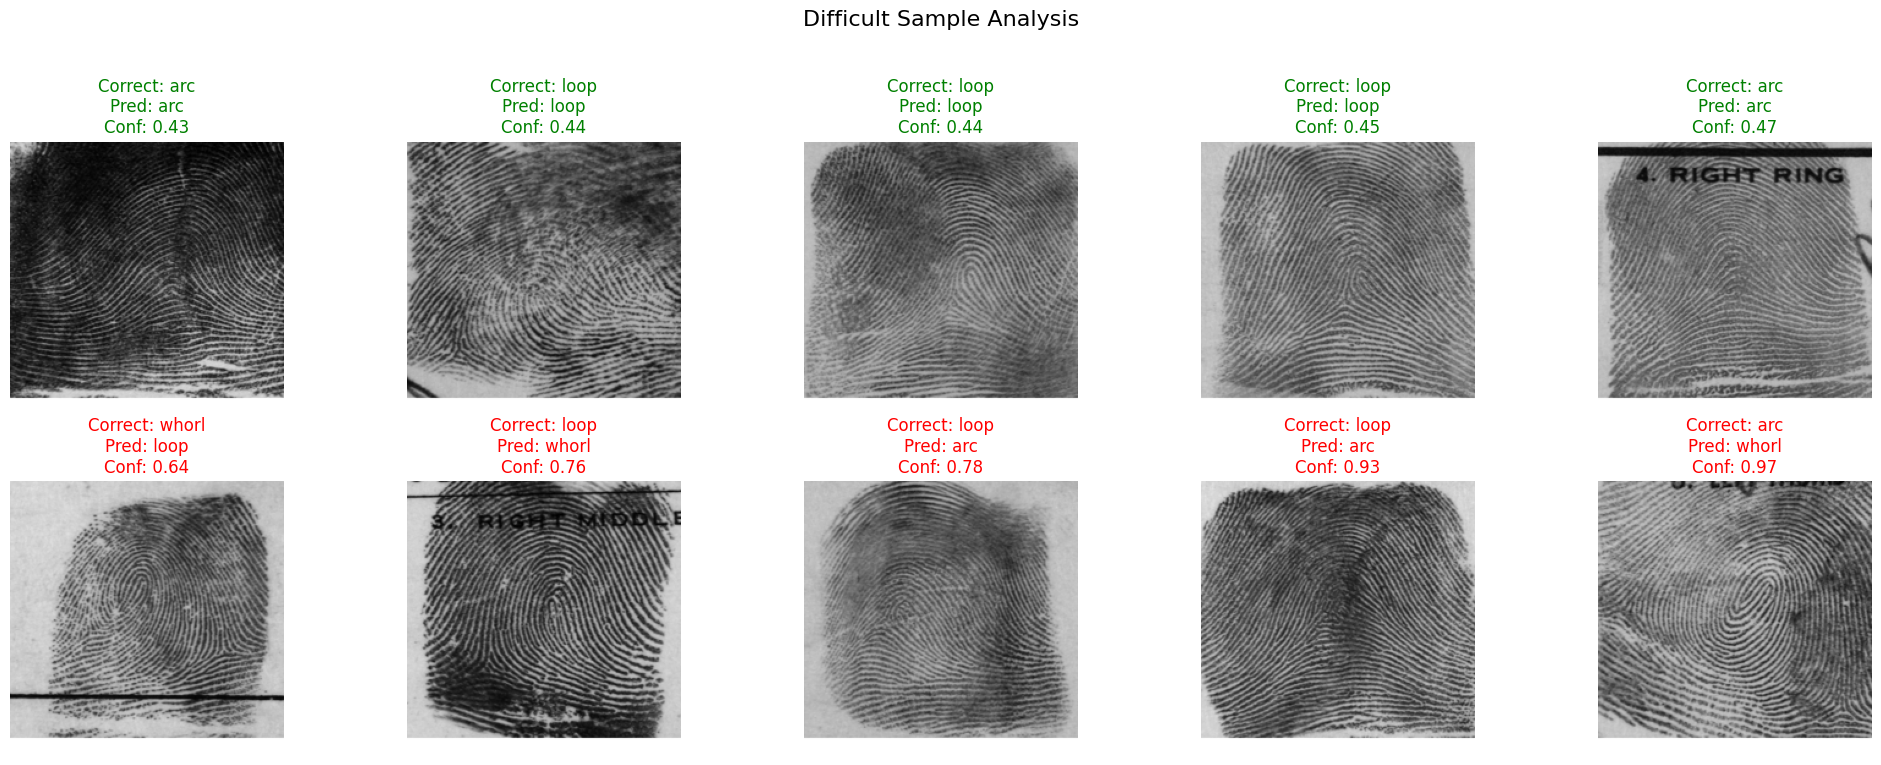

In [ ]:
# ============================================
# SECTION 14: DIFFICULT SAMPLES ANALYSIS
# ============================================

def analyze_difficult_samples(test_generator, predictions, true_classes, predicted_classes, class_names, num_samples=5):
    """Analyze samples that are most difficult to classify (lowest confidence correct & incorrect)"""

    filenames = test_generator.filenames
    max_confidences = np.max(predictions, axis=1)

    # Lowest confidence correct predictions
    correct_mask = true_classes == predicted_classes
    correct_conf = max_confidences[correct_mask]
    correct_indices = np.where(correct_mask)[0]
    lowest_conf_correct_indices = correct_indices[np.argsort(correct_conf)[:num_samples]]

    # Highest confidence incorrect predictions
    incorrect_mask = true_classes != predicted_classes
    incorrect_conf = max_confidences[incorrect_mask]
    incorrect_indices = np.where(incorrect_mask)[0]
    highest_conf_incorrect_indices = incorrect_indices[np.argsort(incorrect_conf)[-num_samples:]]

    # Visualize samples
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 8))
    fig.suptitle('Difficult Sample Analysis', fontsize=16)

    # Plot lowest confidence correct
    for i, idx in enumerate(lowest_conf_correct_indices):
        img_path = os.path.join(TEST_PATH, filenames[idx])
        img = cv2.imread(img_path)
        axes[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        title = (f"Correct: {class_names[true_classes[idx]].split('_')[1]}\n"
                 f"Pred: {class_names[predicted_classes[idx]].split('_')[1]}\n"
                 f"Conf: {max_confidences[idx]:.2f}")
        axes[0, i].set_title(title, color='green')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_ylabel('Lowest Confidence\n(Correct)', fontsize=12)

    # Plot highest confidence incorrect
    for i, idx in enumerate(highest_conf_incorrect_indices):
        img_path = os.path.join(TEST_PATH, filenames[idx])
        img = cv2.imread(img_path)
        axes[1, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        title = (f"Correct: {class_names[true_classes[idx]].split('_')[1]}\n"
                 f"Pred: {class_names[predicted_classes[idx]].split('_')[1]}\n"
                 f"Conf: {max_confidences[idx]:.2f}")
        axes[1, i].set_title(title, color='red')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_ylabel('Highest Confidence\n(Incorrect)', fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('/content/results/difficult_samples_analysis.png', dpi=100)
    plt.show()

print("\nAnalyzing difficult samples...")
analyze_difficult_samples(test_generator, ensemble_predictions, true_classes, ensemble_predicted_classes, class_names)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
best_eff_model.save('/content/drive/MyDrive/best_efficientnet_model_4.keras')
best_inc_model.save('/content/drive/MyDrive/.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/best_efficientnet_model_4.keras")
files.download("/content/drive/MyDrive/best_inception_model_4.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: /content/drive/MyDrive/best_inception_model_4.keras

In [ ]:
# Run this code cell
import shutil

# Copy models to Drive
shutil.copy('/content/models/best_model_efficientnet_s2_finetuned.keras',
            '/content/drive/MyDrive/best_efficientnet_model_final.keras')
shutil.copy('/content/models/best_model_inceptionv3_s2_finetuned.keras',
            '/content/drive/MyDrive/best_inception_model_final.keras')

print("✓ Models copied to Google Drive!")


✓ Models copied to Google Drive!


In [ ]:
# ============================================
# SECTION 15: LOAD AND PREDICT WITH ENSEMBLE
# ============================================

# Enable unsafe deserialization
tf.keras.config.enable_unsafe_deserialization()

# Define custom preprocessing layers
class EfficientNetPreprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(EfficientNetPreprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return efficientnet_preprocess(inputs)

    def get_config(self):
        return super(EfficientNetPreprocessing, self).get_config()

class InceptionV3Preprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(InceptionV3Preprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return inception_preprocess(inputs)

    def get_config(self):
        return super(InceptionV3Preprocessing, self).get_config()

# Define custom objects
custom_objects = {
    'EfficientNetPreprocessing': EfficientNetPreprocessing,
    'InceptionV3Preprocessing': InceptionV3Preprocessing
}



# Load the saved models from Google Drive
try:
    loaded_eff_model = tf.keras.models.load_model(
        '/content/drive/MyDrive/best_efficientnet_model_4.keras',
        custom_objects=custom_objects,
        compile=False
    )
    loaded_inc_model = tf.keras.models.load_model(
        '/content/drive/MyDrive/best_inception_model_4.keras',
        custom_objects=custom_objects,
        compile=False
    )
    print("Models loaded successfully!")
except Exception as e:
    print(f"Error loading models: {e}")

# Assume you have a new image you want to classify
# Replace '/content/drive/MyDrive/path/to/your/new_image.png' with the actual path
# Make sure the image is in RGB format and has the correct size (IMG_SIZE x IMG_SIZE)
# For demonstration, let's use an image from the test set
example_image_path = os.path.join(TEST_PATH, test_generator.filenames[0])
print(f"\nUsing example image: {example_image_path}")

# Load and preprocess the new image
new_image = cv2.imread(example_image_path)
new_image = cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB) # Ensure RGB
new_image = cv2.resize(new_image, (IMG_SIZE, IMG_SIZE)) # Resize
new_image = new_image.astype(np.float32) # Convert to float32 as expected by models

# Debugging: Print shape and dtype before TTA prediction
print(f"Shape of new_image before TTA: {new_image.shape}")
print(f"Dtype of new_image before TTA: {new_image.dtype}")


# It's important to preprocess the image the same way it was done during training
# However, since TTA is used during inference, we apply TTA here.
# The TTA class already handles the base preprocessing for each model internally.

# Get predictions with TTA
# Ensure the image passed to TTA is 3-channel
tta_eff_loaded = TestTimeAugmentation(loaded_eff_model, IMG_SIZE=IMG_SIZE, augmentations=3)
tta_inc_loaded = TestTimeAugmentation(loaded_inc_model, IMG_SIZE=IMG_SIZE, augmentations=3)


# Add batch dimension for prediction - This is handled by TTA predict method
predictions_eff_single = tta_eff_loaded.predict(new_image)
predictions_inc_single = tta_inc_loaded.predict(new_image)


# Perform weighted ensemble prediction
ensemble_prediction_single = (ENSEMBLE_WEIGHTS['efficientnet'] * predictions_eff_single +
                             ENSEMBLE_WEIGHTS['inception'] * predictions_inc_single)

# Get the predicted class index and name
predicted_class_index = np.argmax(ensemble_prediction_single)
predicted_class_name = class_names[predicted_class_index]

# Get the confidence score
confidence_score = np.max(ensemble_prediction_single)

print(f"\nEnsemble Prediction for the image:")
print(f"Predicted Class: {predicted_class_name}")
print(f"Confidence: {confidence_score:.4f}")
print(f"Raw Predictions: {ensemble_prediction_single[0]}")

# Display the image with the prediction
plt.figure(figsize=(6, 6))
plt.imshow(new_image.astype(np.uint8)) # Convert back to uint8 for displaying
plt.title(f"Predicted: {predicted_class_name} (Confidence: {confidence_score:.2f})")
plt.axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# run where you trained/saved the model (python script / notebook)

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, Lambda
import tensorflow as tf

# load original model (if this step succeeds)
orig = load_model("/content/drive/MyDrive/Fingerprint Recognition/best_efficientnet_model.keras", compile=False)
print("orig input_shape:", getattr(orig, "input_shape", None))

# create wrapper that accepts RGB and converts to grayscale for the original model
inp = Input(shape=(224, 224, 3))               # use correct H,W for your model
gray = Lambda(lambda x: tf.image.rgb_to_grayscale(x))(inp)
out = orig(gray)
wrapper = Model(inputs=inp, outputs=out)
wrapper.save("efficientnet_rgb.keras")
print("Saved wrapper as efficientnet_rgb.keras")

In [ ]:
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input
import tensorflow as tf

# Load your original EfficientNet / InceptionV3 model
orig = load_model("/content/drive/MyDrive/Fingerprint Recognition/best_efficientnet_model.keras", compile=False)
print("Loaded model input shape:", orig.input_shape)

# Create a wrapper that enforces the RGB input shape
# FIX: Use the correct shape (224, 224, 3) matching the loaded model
inp = Input(shape=(224, 224, 3))
out = orig(inp)
wrapper = Model(inputs=inp, outputs=out)

# Save the corrected RGB-compatible model
wrapper.save("efficientnet_rgb_fixed.keras")
print("✅ Saved fixed model as efficientnet_rgb_fixed.keras")

# Optional: Verify the wrapper model's input shape
print("Wrapper model input shape:", wrapper.input_shape)

In [ ]:
# In Colab - Check the saved models
import os
import tensorflow as tf

tf.keras.config.enable_unsafe_deserialization()

# Define the custom layers
class EfficientNetPreprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(EfficientNetPreprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return efficientnet_preprocess(inputs)

    def get_config(self):
        return super(EfficientNetPreprocessing, self).get_config()

class InceptionV3Preprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(InceptionV3Preprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return inception_preprocess(inputs)

    def get_config(self):
        return super(InceptionV3Preprocessing, self).get_config()

custom_objects = {
    'EfficientNetPreprocessing': EfficientNetPreprocessing,
    'InceptionV3Preprocessing': InceptionV3Preprocessing
}

# Check what files exist
print("Files in /content/models/:")
for f in os.listdir('/content/models/'):
    path = f'/content/models/{f}'
    size = os.path.getsize(path) / (1024*1024)
    print(f"  {f}: {size:.1f} MB")

# Try loading the EfficientNet model
print("\nTrying to load EfficientNet...")
try:
    eff_model = tf.keras.models.load_model(
        '/content/models/best_model_efficientnet_s2_finetuned.keras',
        custom_objects=custom_objects,
        compile=False
    )
    print(f"✅ Input shape: {eff_model.input_shape}")
    print(f"✅ Output shape: {eff_model.output_shape}")
except Exception as e:
    print(f"❌ Error: {e}")

# Also check what's in Google Drive
print("\n\nFiles in Google Drive:")
for f in os.listdir('/content/drive/MyDrive/'):
    if 'efficient' in f.lower() or 'inception' in f.lower():
        path = f'/content/drive/MyDrive/{f}'
        size = os.path.getsize(path) / (1024*1024)
        print(f"  {f}: {size:.1f} MB")


Files in /content/models/:
  best_model_efficientnet_s1.keras: 44.1 MB
  best_model_inceptionv3_s2_finetuned.keras: 256.9 MB
  best_model_efficientnet_s2_finetuned.keras: 69.1 MB
  best_model_inceptionv3_s1.keras: 145.9 MB

Trying to load EfficientNet...
✅ Input shape: (None, 224, 224, 3)
✅ Output shape: (None, 3)


Files in Google Drive:
  best_efficientnet_model_4.keras: 25.6 MB
  best_efficientnet_model_final.keras: 69.1 MB
  best_inception_model_final.keras: 256.9 MB


In [ ]:
import shutil

# Delete the old file from Drive
import os
old_file = '/content/drive/MyDrive/best_efficientnet_model_final.keras'
if os.path.exists(old_file):
    os.remove(old_file)
    print("✓ Deleted old corrupted file")

# Copy the WORKING file from /content/models/
shutil.copy('/content/models/best_model_efficientnet_s2_finetuned.keras',
            '/content/drive/MyDrive/best_efficientnet_model_NEW.keras')

print("✓ Copied working EfficientNet model to Drive!")
print("File size:", os.path.getsize('/content/drive/MyDrive/best_efficientnet_model_NEW.keras') / (1024*1024), "MB")

# Verify it loads correctly
import tensorflow as tf
tf.keras.config.enable_unsafe_deserialization()

# Define custom layers
class EfficientNetPreprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(EfficientNetPreprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return efficientnet_preprocess(inputs)

    def get_config(self):
        return super(EfficientNetPreprocessing, self).get_config()

class InceptionV3Preprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(InceptionV3Preprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return inception_preprocess(inputs)

    def get_config(self):
        return super(InceptionV3Preprocessing, self).get_config()

custom_objects = {
    'EfficientNetPreprocessing': EfficientNetPreprocessing,
    'InceptionV3Preprocessing': InceptionV3Preprocessing
}

# Verify the file in Drive loads correctly
test_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/best_efficientnet_model_NEW.keras',
    custom_objects=custom_objects,
    compile=False
)
print(f"✅ VERIFIED: Input shape: {test_model.input_shape}")
print(f"✅ VERIFIED: Output shape: {test_model.output_shape}")


✓ Deleted old corrupted file
✓ Copied working EfficientNet model to Drive!
File size: 69.13532447814941 MB
✅ VERIFIED: Input shape: (None, 224, 224, 3)
✅ VERIFIED: Output shape: (None, 3)


In [ ]:
# ============================================
# EXPORT MODELS IN SAVEDMODEL FORMAT
# ============================================

import tensorflow as tf

# Enable unsafe deserialization
tf.keras.config.enable_unsafe_deserialization()

# Define custom layers
class EfficientNetPreprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(EfficientNetPreprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return efficientnet_preprocess(inputs)

    def get_config(self):
        return super(EfficientNetPreprocessing, self).get_config()

class InceptionV3Preprocessing(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(InceptionV3Preprocessing, self).__init__(**kwargs)

    def call(self, inputs):
        return inception_preprocess(inputs)

    def get_config(self):
        return super(InceptionV3Preprocessing, self).get_config()

custom_objects = {
    'EfficientNetPreprocessing': EfficientNetPreprocessing,
    'InceptionV3Preprocessing': InceptionV3Preprocessing
}

# Load the working models
print("Loading models...")
eff_model = tf.keras.models.load_model(
    '/content/models/best_model_efficientnet_s2_finetuned.keras',
    custom_objects=custom_objects,
    compile=False
)
inc_model = tf.keras.models.load_model(
    '/content/models/best_model_inceptionv3_s2_finetuned.keras',
    custom_objects=custom_objects,
    compile=False
)
print("✅ Models loaded successfully!")

# Export in SavedModel format (cross-version compatible)
print("\nExporting in SavedModel format...")
eff_model.export('/content/models/efficientnet_savedmodel')
inc_model.export('/content/models/inceptionv3_savedmodel')
print("✅ Exported to SavedModel format!")

# Zip the directories for easy download
import shutil
shutil.make_archive('/content/efficientnet_savedmodel', 'zip', '/content/models/efficientnet_savedmodel')
shutil.make_archive('/content/inceptionv3_savedmodel', 'zip', '/content/models/inceptionv3_savedmodel')
print("✅ Created zip files!")

# Copy to Drive
shutil.copy('/content/efficientnet_savedmodel.zip', '/content/drive/MyDrive/efficientnet_savedmodel.zip')
shutil.copy('/content/inceptionv3_savedmodel.zip', '/content/drive/MyDrive/inceptionv3_savedmodel.zip')
print("✅ Copied to Google Drive!")

print("\nDownload these files:")
print("  - efficientnet_savedmodel.zip")
print("  - inceptionv3_savedmodel.zip")

# Or download directly
from google.colab import files
files.download('/content/efficientnet_savedmodel.zip')
files.download('/content/inceptionv3_savedmodel.zip')


Loading models...
✅ Models loaded successfully!

Exporting in SavedModel format...
Saved artifact at '/content/models/efficientnet_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')]
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136737868436432: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136737868433360: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136730278322320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136730278321360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136730278315216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136730278323088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136730278323856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136730278322512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136730278324048: Tensor

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>